In [3]:
# Cell 0 — Install dependencies (first session only)
!pip install lifetimes xgboost lightgbm catboost shap mlflow lime umap-learn optuna --quiet


In [1]:
# Cell 1 — Environment Setup
import os, sys
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

CLV_BASE_DIR = "/content/drive/MyDrive/clv-prediction-engine"
os.environ["CLV_BASE_DIR"] = CLV_BASE_DIR
if CLV_BASE_DIR not in sys.path:
    sys.path.insert(0, CLV_BASE_DIR)

from src.config import setup_logging, setup_directories
setup_logging()
setup_directories()
print(f"Environment ready. Base dir: {CLV_BASE_DIR}")


Mounted at /content/drive
Environment ready. Base dir: /content/drive/MyDrive/clv-prediction-engine


In [5]:
# Cell 2 — Imports
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings("ignore")

from src.config import MODELS_DIR, GRAPHS_DIR, FEATURE_COLS, FILEPATH, SPLIT_DAYS, RANDOM_SEED
from src.data_ingestion import load_data, clean_data
from src.feature_engineering import build_hybrid_features
from src.modeling import LOG_PRED_MAX
from src.segmentation import run_segmentation_pipeline, assign_segments, SEGMENT_LABELS

print("All imports successful")


All imports successful


In [6]:
# Cell 3 — Load Data & CLV Artifacts
# Loads existing CLV champion model and recomputes predictions for the
# Segment x CLV heatmap. Requires main_execution.ipynb to have run first.

from sklearn.metrics import r2_score

bundle_path = MODELS_DIR / "clv_champion_bundle.pkl"

print("[1/3] Loading raw data...")
raw_df   = load_data()
clean_df = clean_data(raw_df)

print("[2/3] Building features...")
X_train, X_test, y_train, y_test, y_test_raw = build_hybrid_features(
    clean_df, raw_df=raw_df, split_days=SPLIT_DAYS
)

print("[3/3] Loading CLV champion model...")
if not bundle_path.exists():
    raise FileNotFoundError(
        f"CLV bundle not found at {bundle_path}.\n"
        "Run main_execution.ipynb first to train and save the champion model."
    )

bundle    = joblib.load(bundle_path)
clv_model = bundle["model"]
print(f"   Champion: {type(clv_model).__name__} | Version: {bundle.get('version', '?')}") 

# Compute CLV predictions for Segment x CLV heatmap
log_preds     = np.clip(clv_model.predict(X_test), 0, LOG_PRED_MAX)
dollar_preds  = np.expm1(log_preds)
dollar_actual = np.expm1(y_test.values)
dollar_r2     = r2_score(dollar_actual, dollar_preds)

print(f"\nData ready")
print(f"   X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"   CLV Dollar R2: {dollar_r2:.4f}")
print(f"   Avg predicted spend: ${dollar_preds.mean():,.2f}")
print(f"   Avg actual spend:    ${dollar_actual.mean():,.2f}")


[1/3] Loading raw data...
[2/3] Building features...
[3/3] Loading CLV champion model...
   Champion: TwoStageRegressor | Version: 2.5.0

Data ready
   X_train: (2695, 16) | X_test: (675, 16)
   CLV Dollar R2: 0.5814
   Avg predicted spend: $533.24
   Avg actual spend:    $690.22


In [7]:
# Cell 4 — Run Segmentation Pipeline
# Runtime: ~4-5 minutes total
#   K-Means + evaluation : ~30 seconds
#   DBSCAN + Optuna      : ~2 minutes  (set tune_dbscan=False to skip)
#   UMAP                 : ~30 seconds
#   t-SNE                : ~60 seconds  (set run_tsne=False to skip)

seg_results = run_segmentation_pipeline(
    X_train      = X_train,
    X_test       = X_test,
    y_test_raw   = y_test_raw,
    dollar_preds = dollar_preds,
    customer_ids = None,
    feature_set  = "extended",
    tune_dbscan  = True,
    run_tsne     = True,
)

print("\nSegmentation pipeline complete!")
print(f"   Optimal clusters (k): {seg_results['optimal_k']}")
print(f"   Silhouette score    : {seg_results['metrics']['silhouette']:.4f}")
print(f"   Davies-Bouldin      : {seg_results['metrics']['davies_bouldin']:.4f}")
print(f"   Calinski-Harabasz   : {seg_results['metrics']['calinski_harabasz']:.0f}")



  SEGMENTATION PIPELINE COMPLETE
  Champion: K-Means (k=2)
  Silhouette Score     : 0.5340  (higher = better, max 1.0)
  Davies-Bouldin Index : 1.2058  (lower = better)
  Calinski-Harabasz    : 1552  (higher = better)
  DBSCAN clusters found: 2
  DBSCAN noise points  : 2.0% of customers
  PCA components used  : 6 (96.8% variance)

  Plots saved to: /content/drive/MyDrive/clv-prediction-engine/artifacts/graphs
  Bundle saved to: /content/drive/MyDrive/clv-prediction-engine/artifacts/models/segmentation_bundle.pkl

Segmentation pipeline complete!
   Optimal clusters (k): 2
   Silhouette score    : 0.5340
   Davies-Bouldin      : 1.2058
   Calinski-Harabasz   : 1552


In [8]:
# Cell 5 — Segmentation Model Leaderboard
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

metrics   = seg_results["metrics"]
X_all     = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
X_scaled  = seg_results["scaler"].transform(X_all[seg_results["cols_used"]].fillna(0))
X_pca_all = seg_results["pca"].transform(X_scaled)

rows = []
for name, labels in [
    ("K-Means",      seg_results["labels"]),
    ("GMM",          seg_results["gmm_labels"]),
    ("Hierarchical", seg_results["hier_labels"]),
]:
    if len(set(labels)) > 1:
        rows.append({
            "Model":             name,
            "Silhouette":        round(silhouette_score(X_pca_all, labels), 4),
            "Davies-Bouldin":    round(davies_bouldin_score(X_pca_all, labels), 4),
            "Calinski-Harabasz": round(calinski_harabasz_score(X_pca_all, labels)),
            "Notes":             f"k={metrics['optimal_k']}",
        })

# DBSCAN - exclude noise
db_labels = seg_results["dbscan_labels"]
db_mask   = db_labels != -1
if db_mask.sum() > 1 and len(set(db_labels[db_mask])) > 1:
    rows.append({
        "Model":             "DBSCAN (excl. noise)",
        "Silhouette":        round(silhouette_score(X_pca_all[db_mask], db_labels[db_mask]), 4),
        "Davies-Bouldin":    round(davies_bouldin_score(X_pca_all[db_mask], db_labels[db_mask]), 4),
        "Calinski-Harabasz": round(calinski_harabasz_score(X_pca_all[db_mask], db_labels[db_mask])),
        "Notes":             f"{metrics['dbscan_noise_pct']:.1f}% noise points",
    })

leaderboard = pd.DataFrame(rows).sort_values("Silhouette", ascending=False).reset_index(drop=True)

print("=" * 75)
print("   SEGMENTATION MODEL LEADERBOARD")
print("   Silhouette: higher = better | Davies-Bouldin: lower = better")
print("   Calinski-Harabasz: higher = better")
print("=" * 75)
print(leaderboard.to_string(index=False))
print("=" * 75)


   SEGMENTATION MODEL LEADERBOARD
   Silhouette: higher = better | Davies-Bouldin: lower = better
   Calinski-Harabasz: higher = better
               Model  Silhouette  Davies-Bouldin  Calinski-Harabasz             Notes
DBSCAN (excl. noise)      0.7207          0.3068                 90 2.0% noise points
        Hierarchical      0.6025          1.2336               1233               k=2
             K-Means      0.5340          1.2058               1552               k=2
                 GMM      0.3783          1.3853               1145               k=2


In [9]:
# Cell 6 — Segment x CLV Business Analysis
# The most business-valuable output: which segments drive future revenue?

customer_df = seg_results["customer_df"]

if customer_df is not None:
    print("=" * 65)
    print("   SEGMENT x CLV BUSINESS SUMMARY")
    print("=" * 65)

    summary = (
        customer_df
        .groupby("Segment_Name")
        .agg(
            N         = ("CLV_Predicted_90d", "count"),
            Avg_CLV   = ("CLV_Predicted_90d", "mean"),
            Total_CLV = ("CLV_Predicted_90d", "sum"),
        )
        .reset_index()
    )
    total_rev = summary["Total_CLV"].sum()
    summary["Revenue_Share_%"] = (summary["Total_CLV"] / total_rev * 100).round(1)
    summary["Avg_CLV"]         = summary["Avg_CLV"].round(2)
    summary["Total_CLV"]       = summary["Total_CLV"].round(2)
    summary = summary.sort_values("Total_CLV", ascending=False).reset_index(drop=True)

    print(summary.to_string(index=False))
    print("=" * 65)

    print("\nCLV Tier Distribution per Segment:")
    tier_ct = pd.crosstab(
        customer_df["Segment_Name"],
        customer_df["CLV_Tier"],
        normalize="index"
    ).round(3) * 100
    print(tier_ct.to_string())
    print(f"\nResults saved: {GRAPHS_DIR}/customer_segments.csv")
else:
    print("customer_df is None — re-run Cell 4 with dollar_preds provided.")


   SEGMENT x CLV BUSINESS SUMMARY
   Segment_Name   N  Avg_CLV  Total_CLV  Revenue_Share_%
Loyal Customers 110  2342.59  257685.38             71.6
      Champions 565   180.98  102252.49             28.4

CLV Tier Distribution per Segment:
CLV_Tier         🐋 Whale  💤 Churned  💰 Mid  📉 Low
Segment_Name                                     
Champions            0.0       49.6   46.2    4.2
Loyal Customers     54.5        0.9   44.5    0.0

Results saved: /content/drive/MyDrive/clv-prediction-engine/artifacts/graphs/customer_segments.csv



--- Plot S1+S2: Elbow Method + Silhouette Score ---


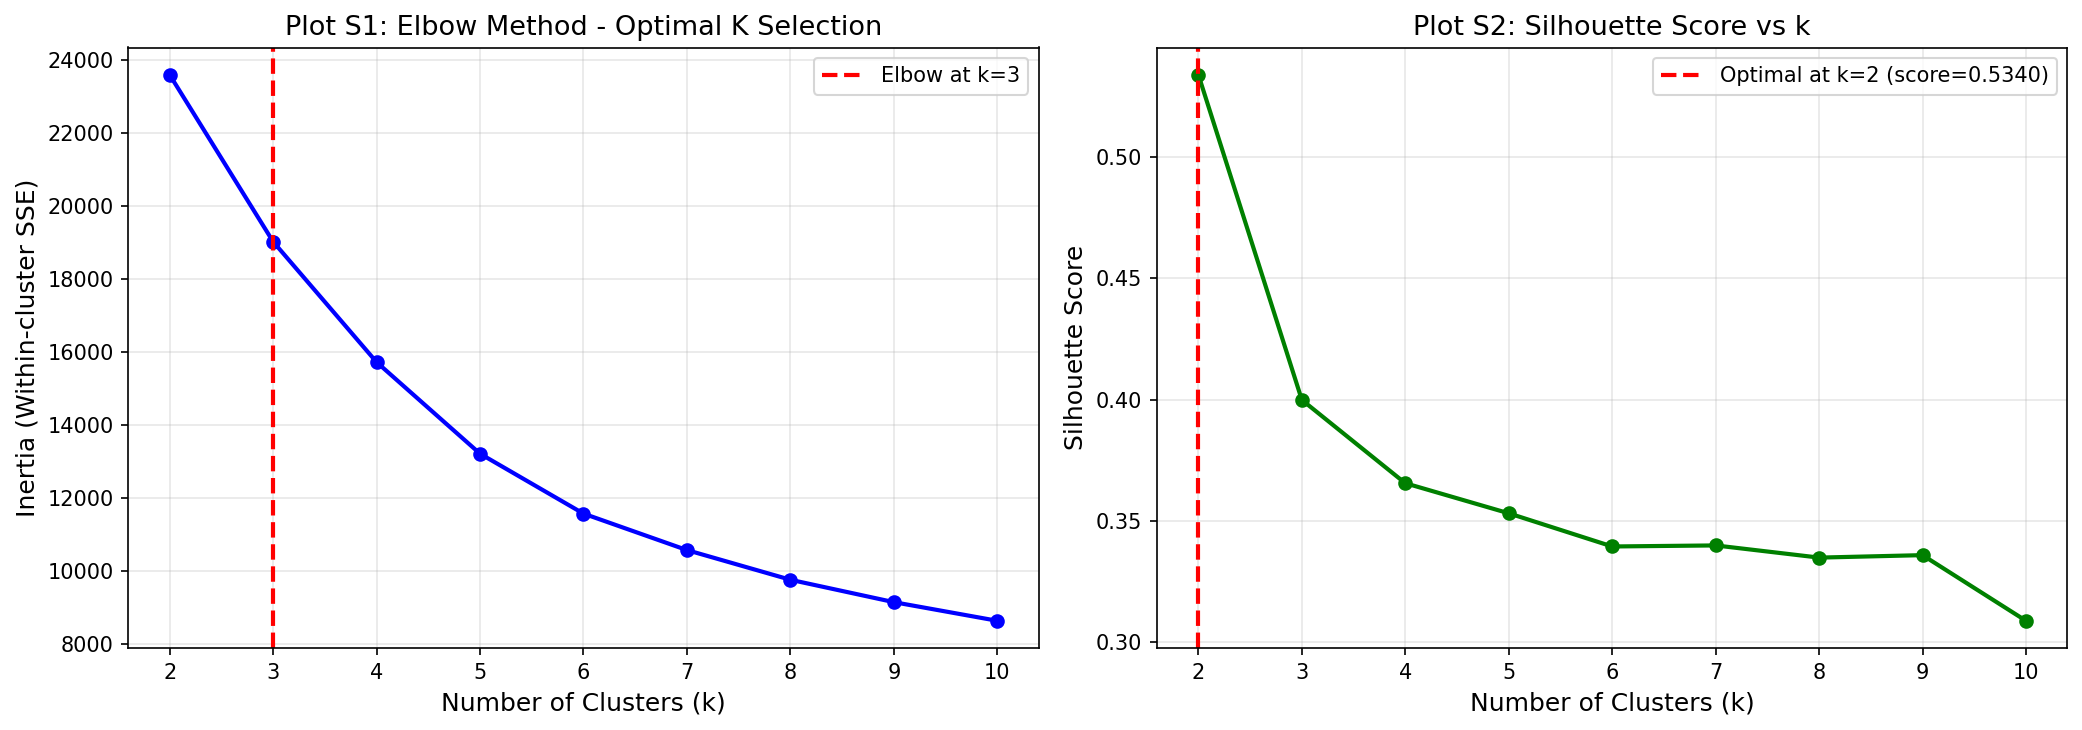


--- Plot S9: PCA Scree + Cumulative Variance ---


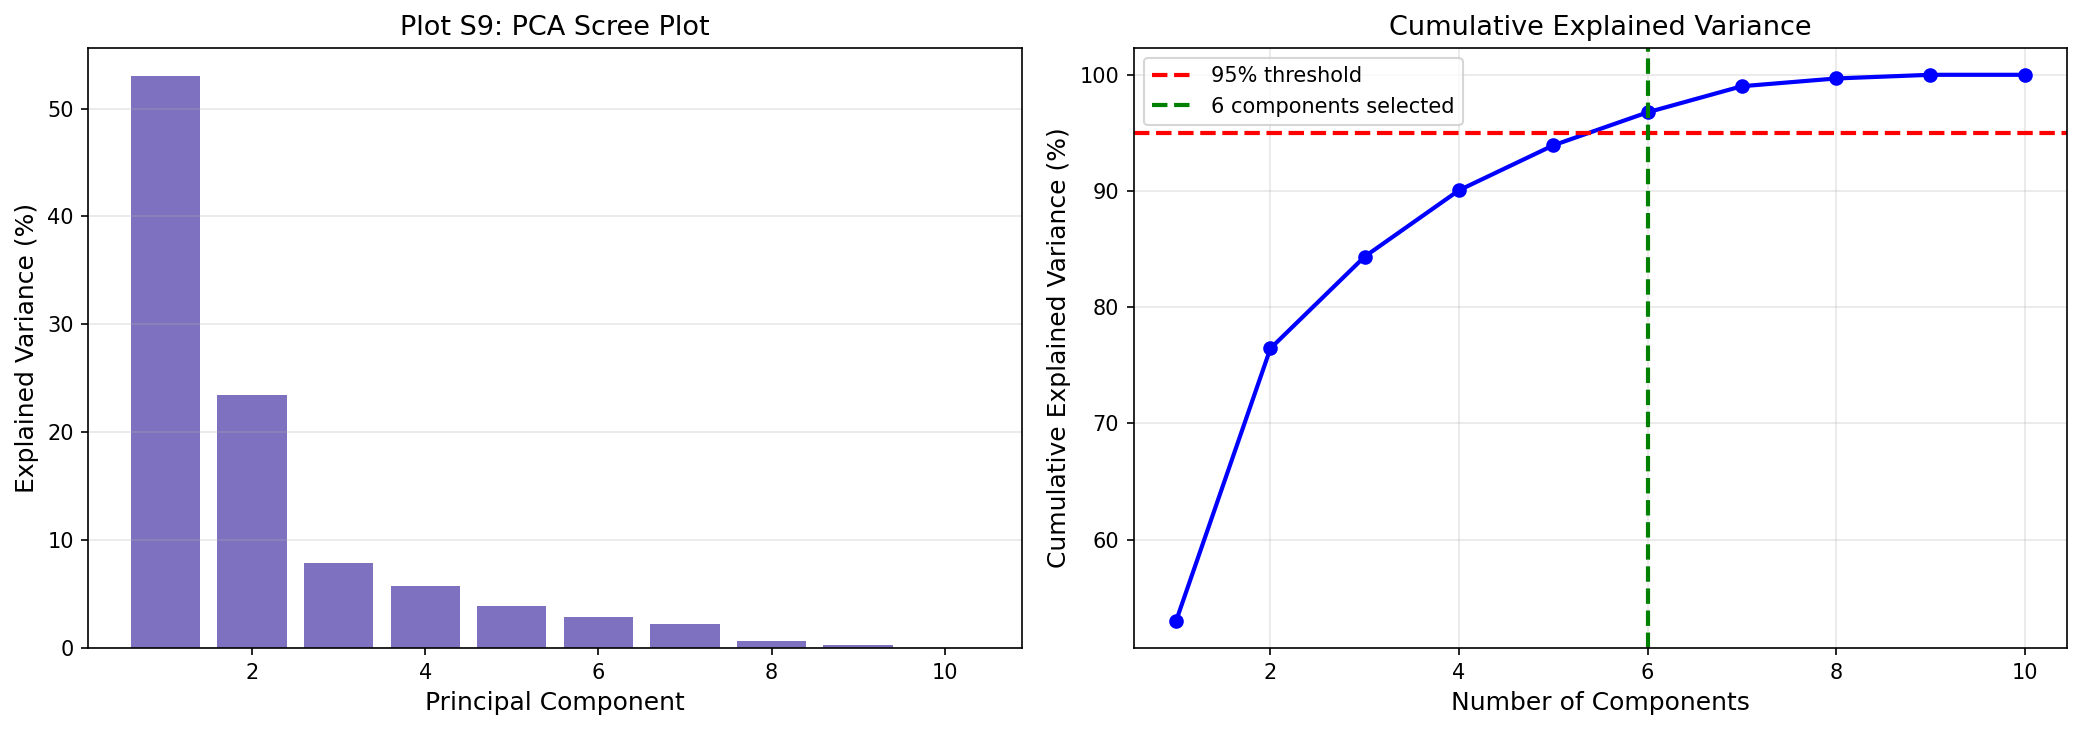


--- Plot S3: UMAP 2D Cluster Embedding ---


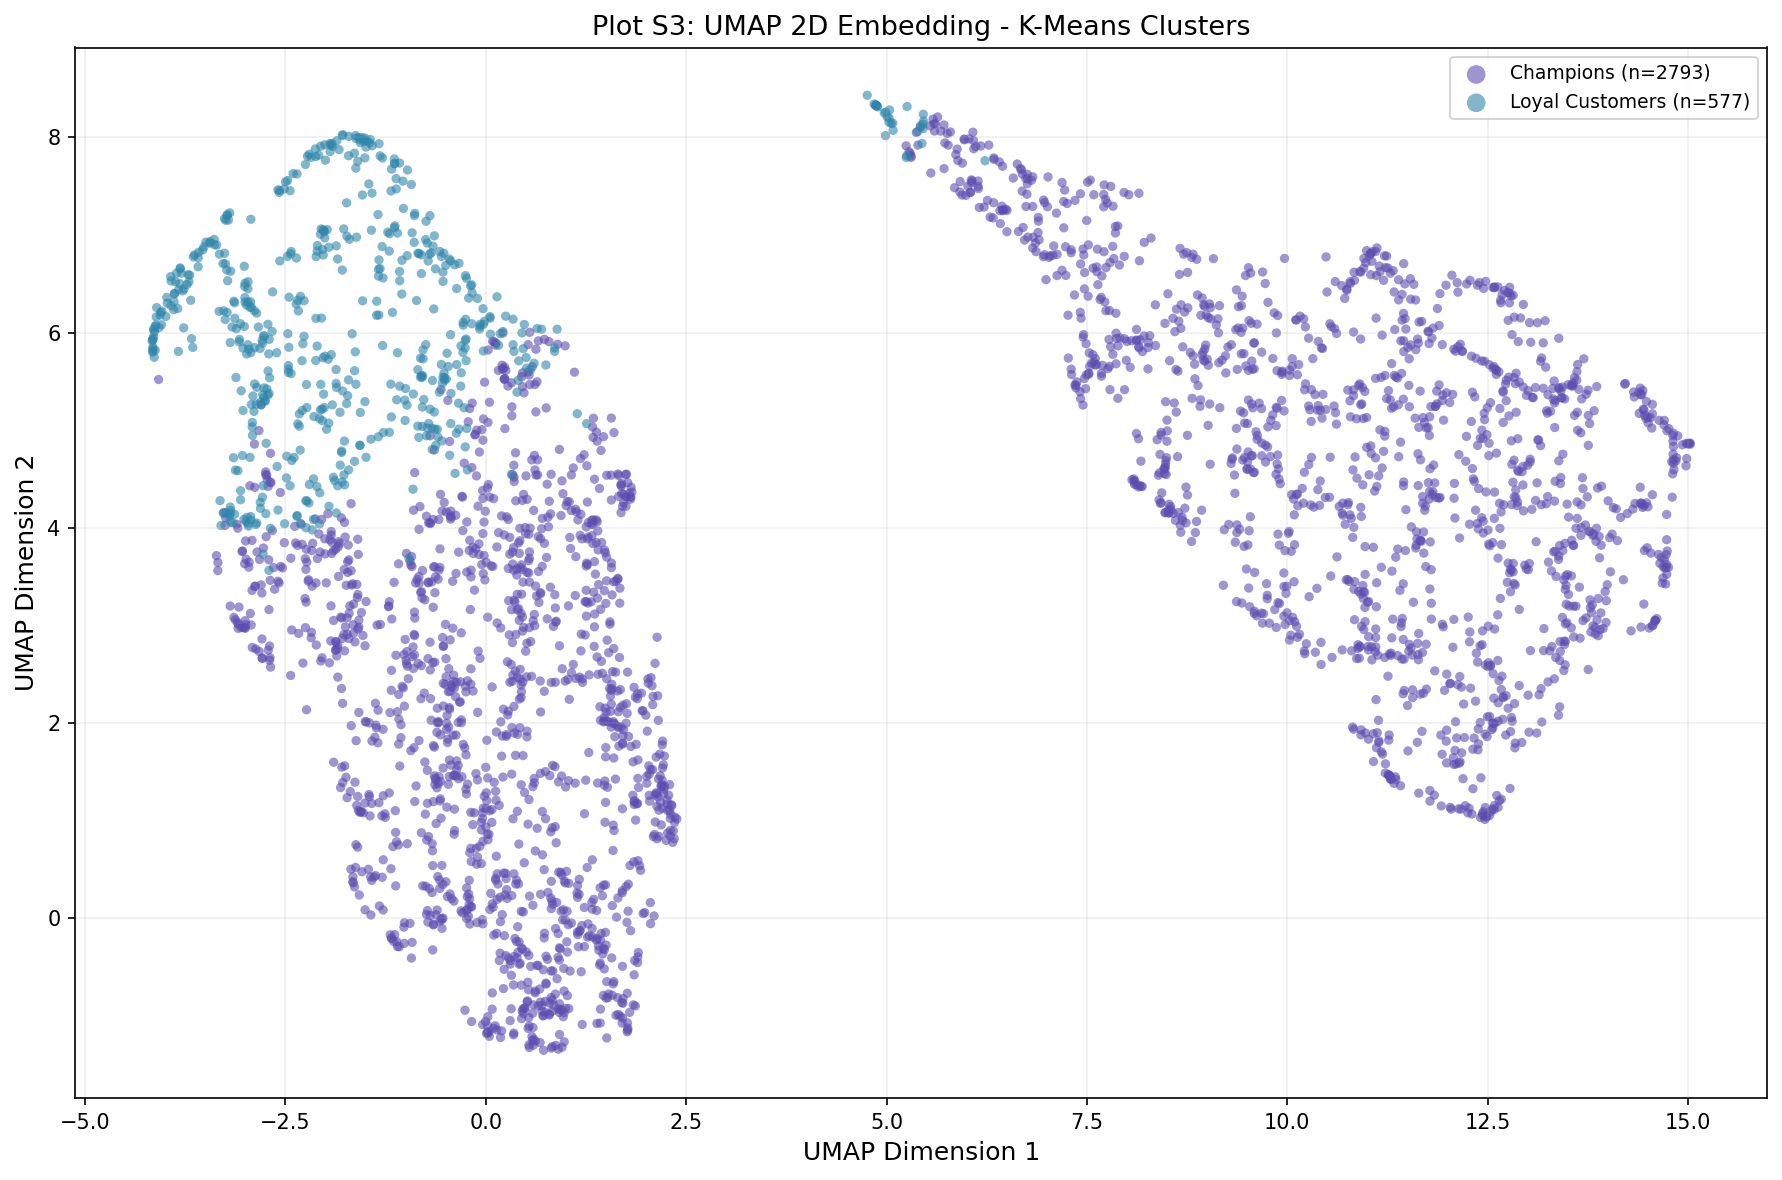


--- Plot S4: t-SNE 2D Cluster Embedding ---


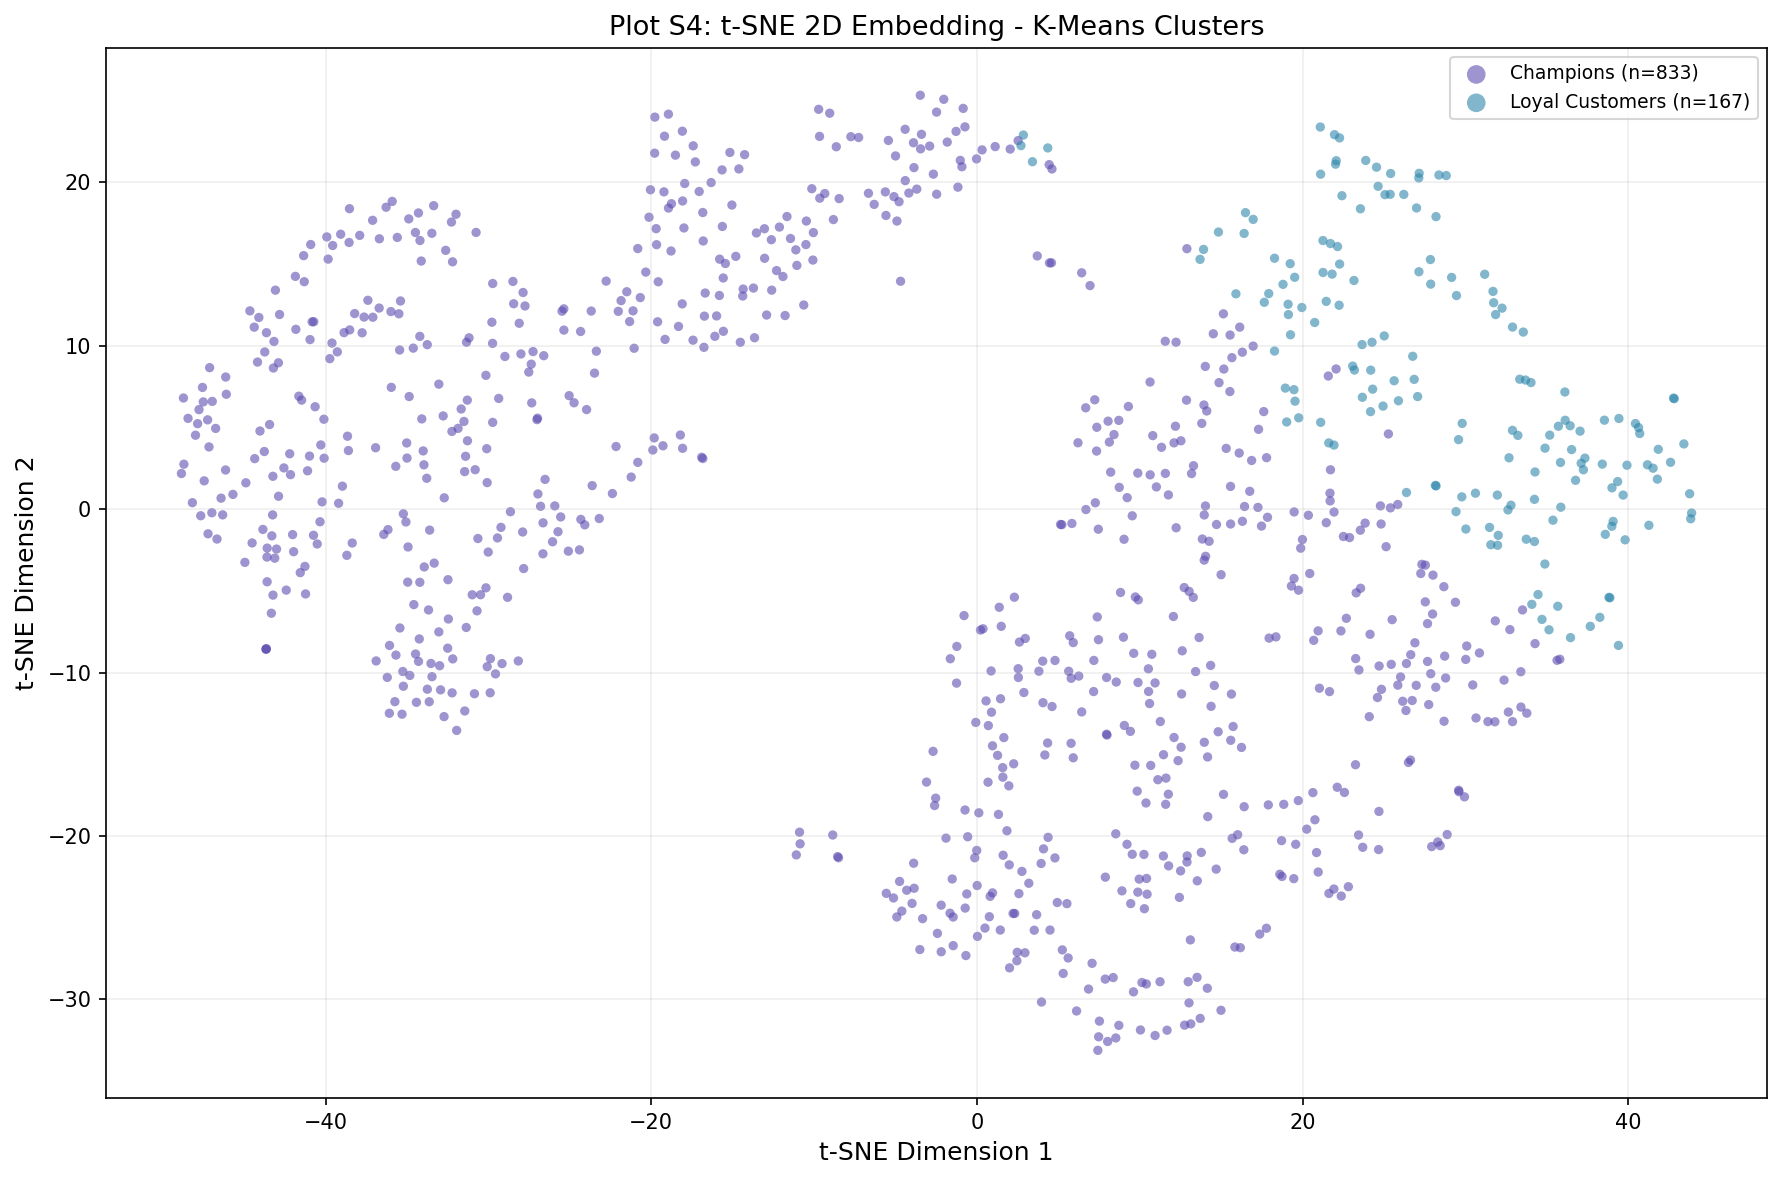


--- Plot S5: Cluster Feature Profile Heatmap ---


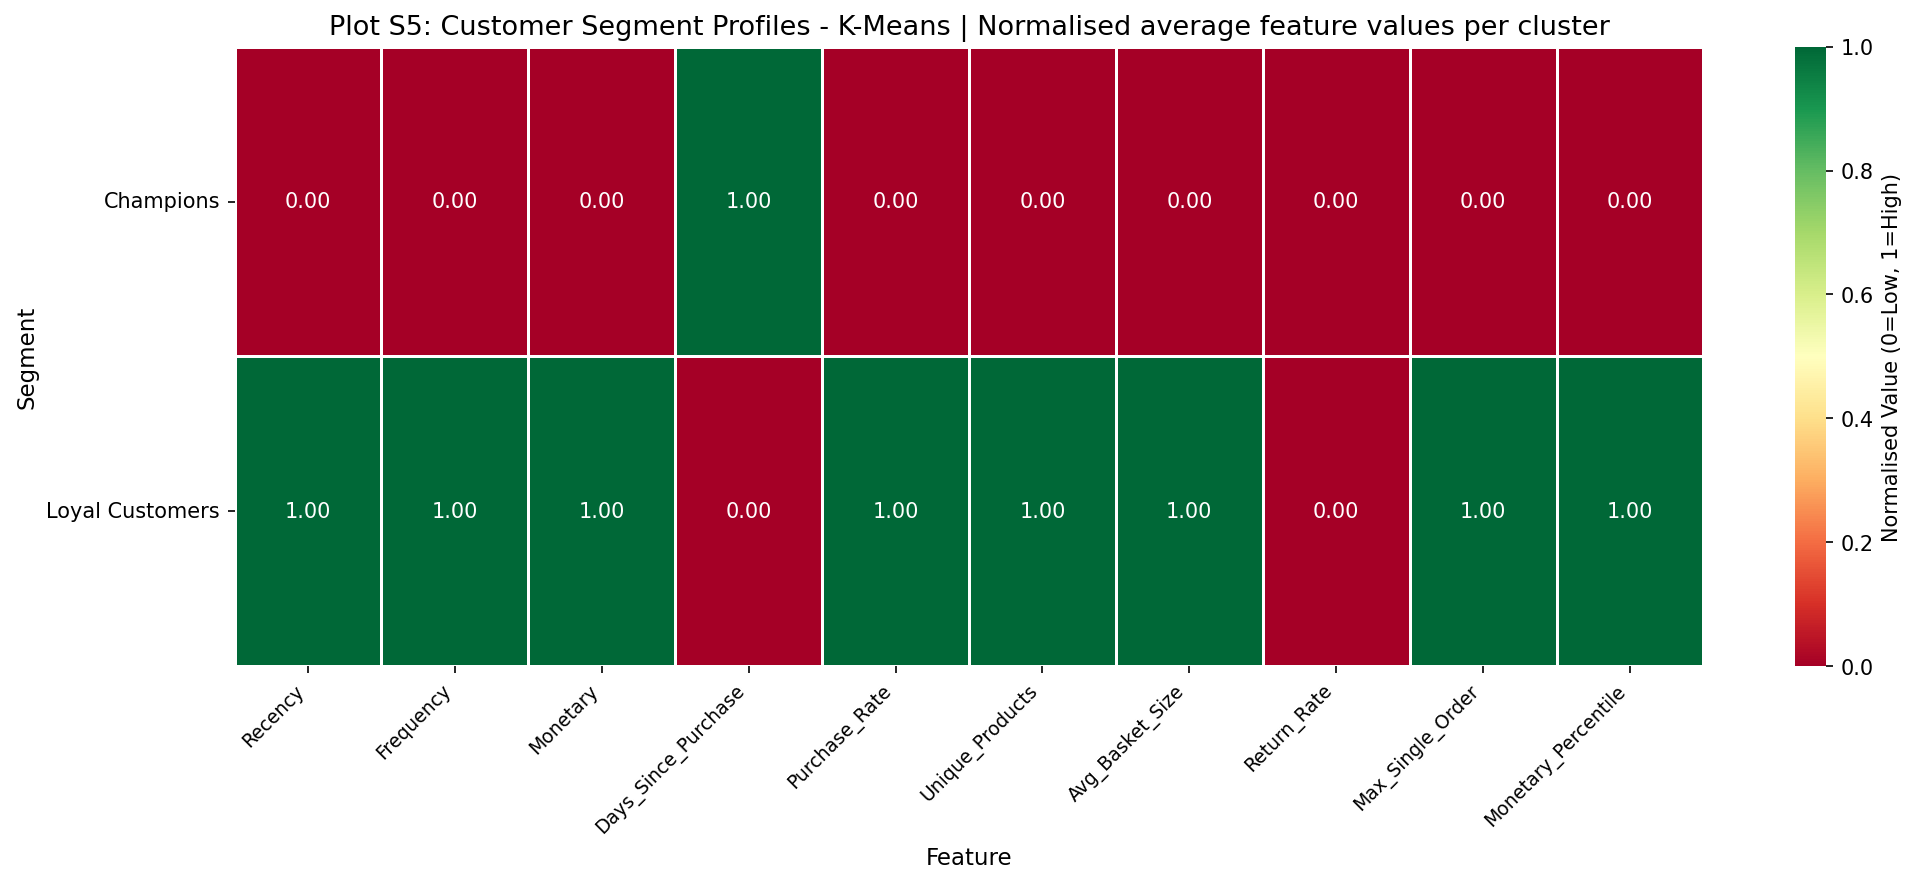


--- Plot S6: Segment x CLV Tier Heatmap ---


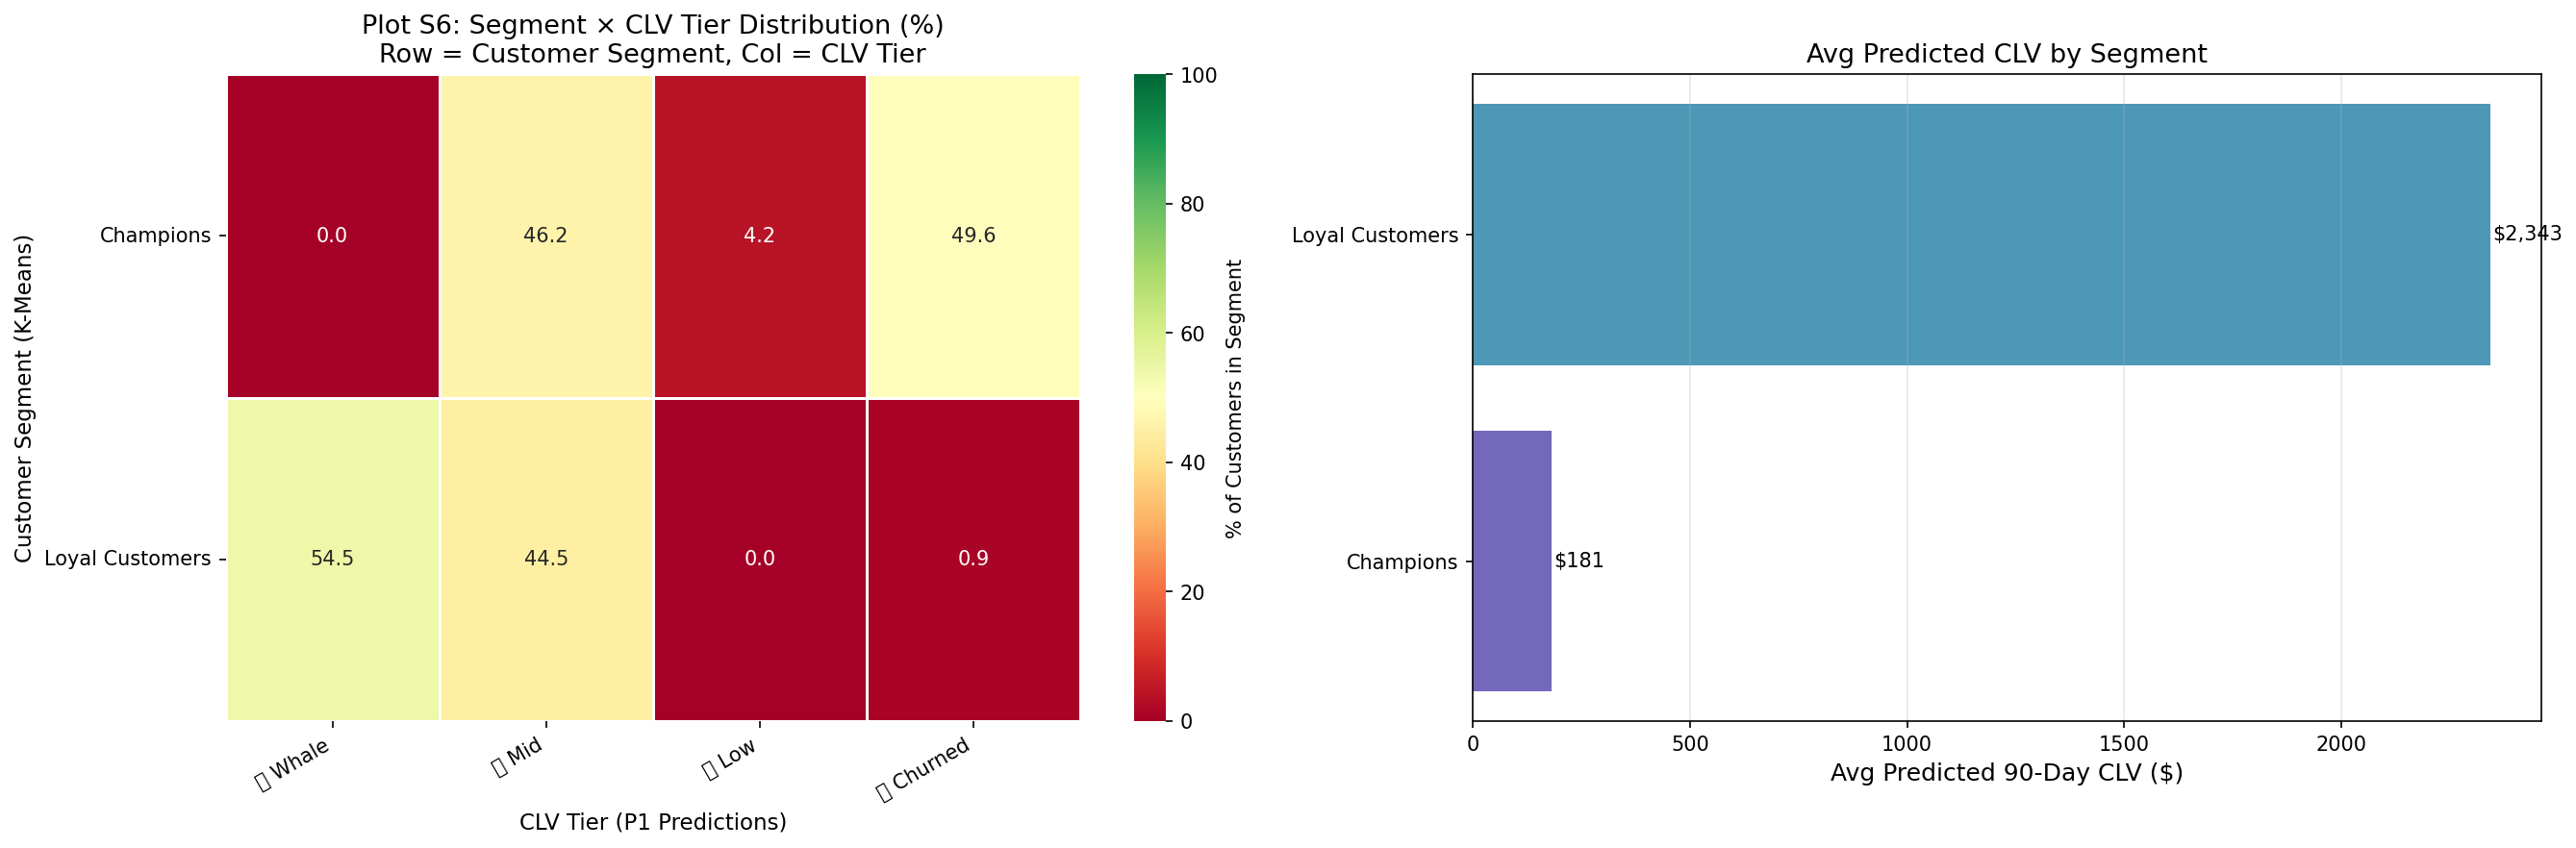


--- Plot S7: Hierarchical Clustering Dendrogram ---


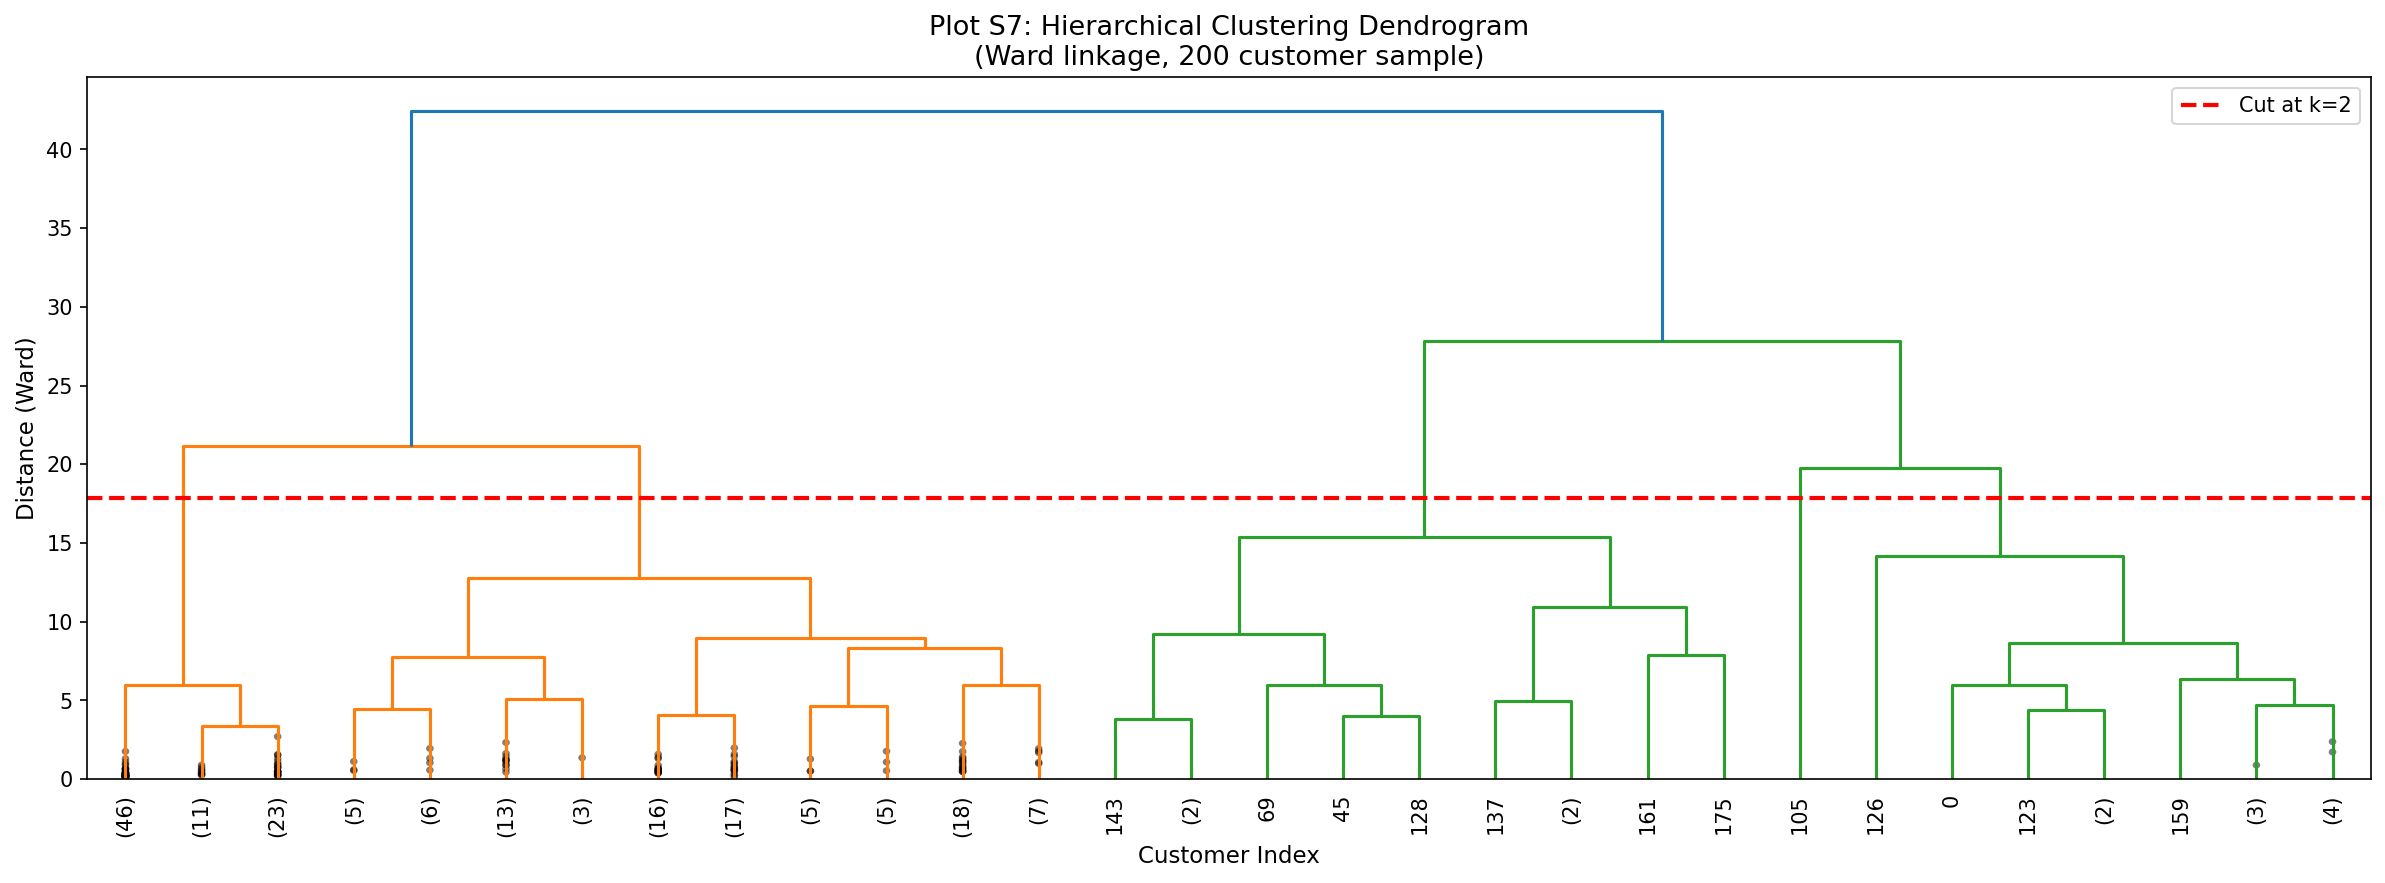


--- Plot S8: RFM 3D Scatter by Segment ---


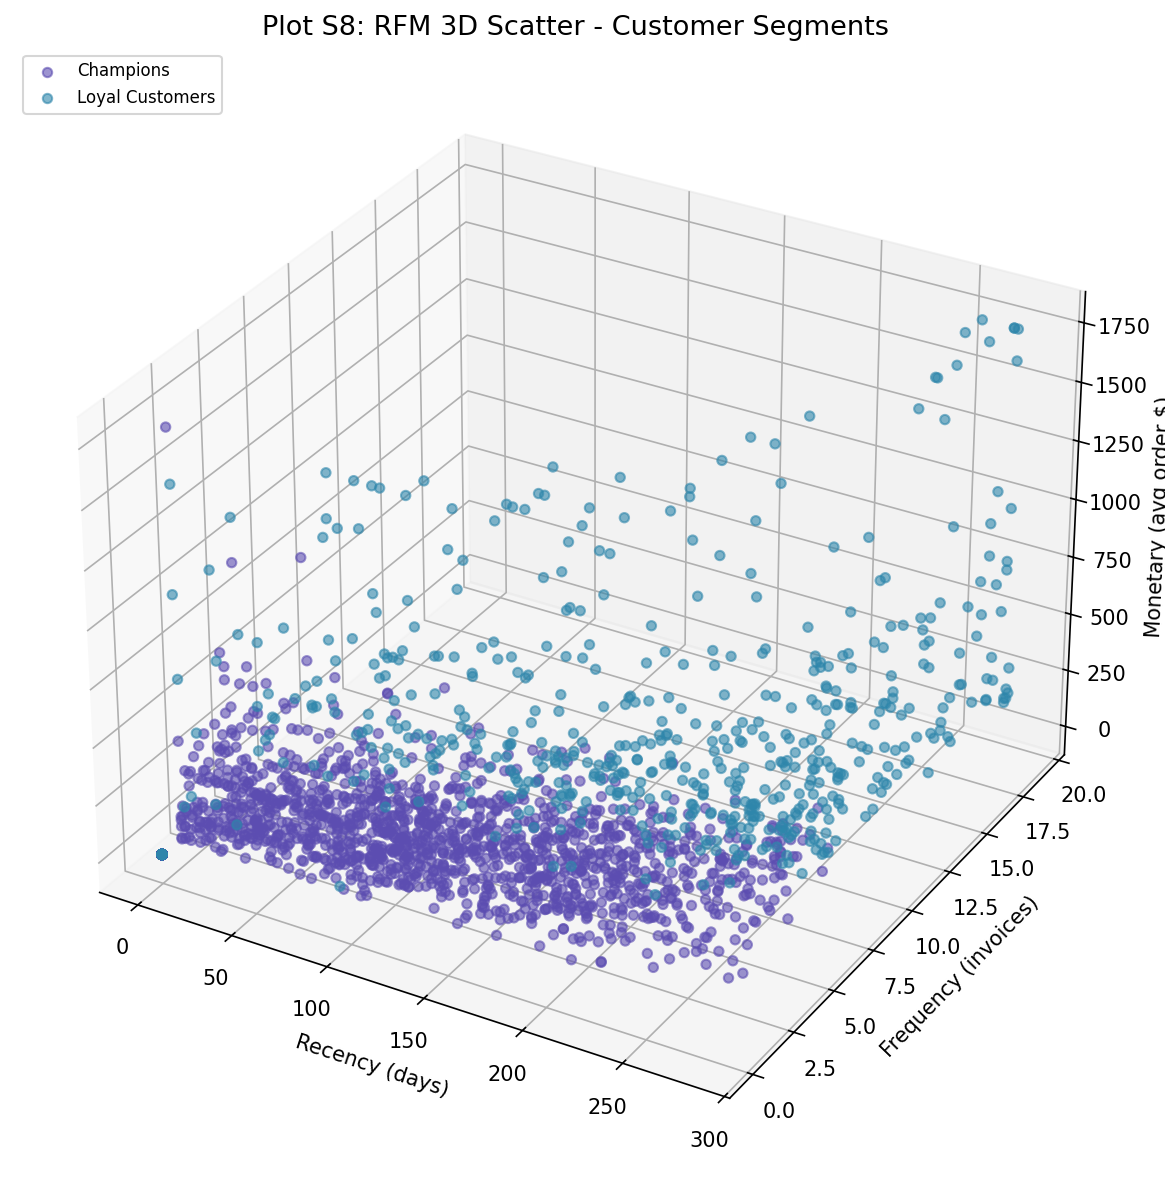


--- Plot S10: DBSCAN Noise Map ---


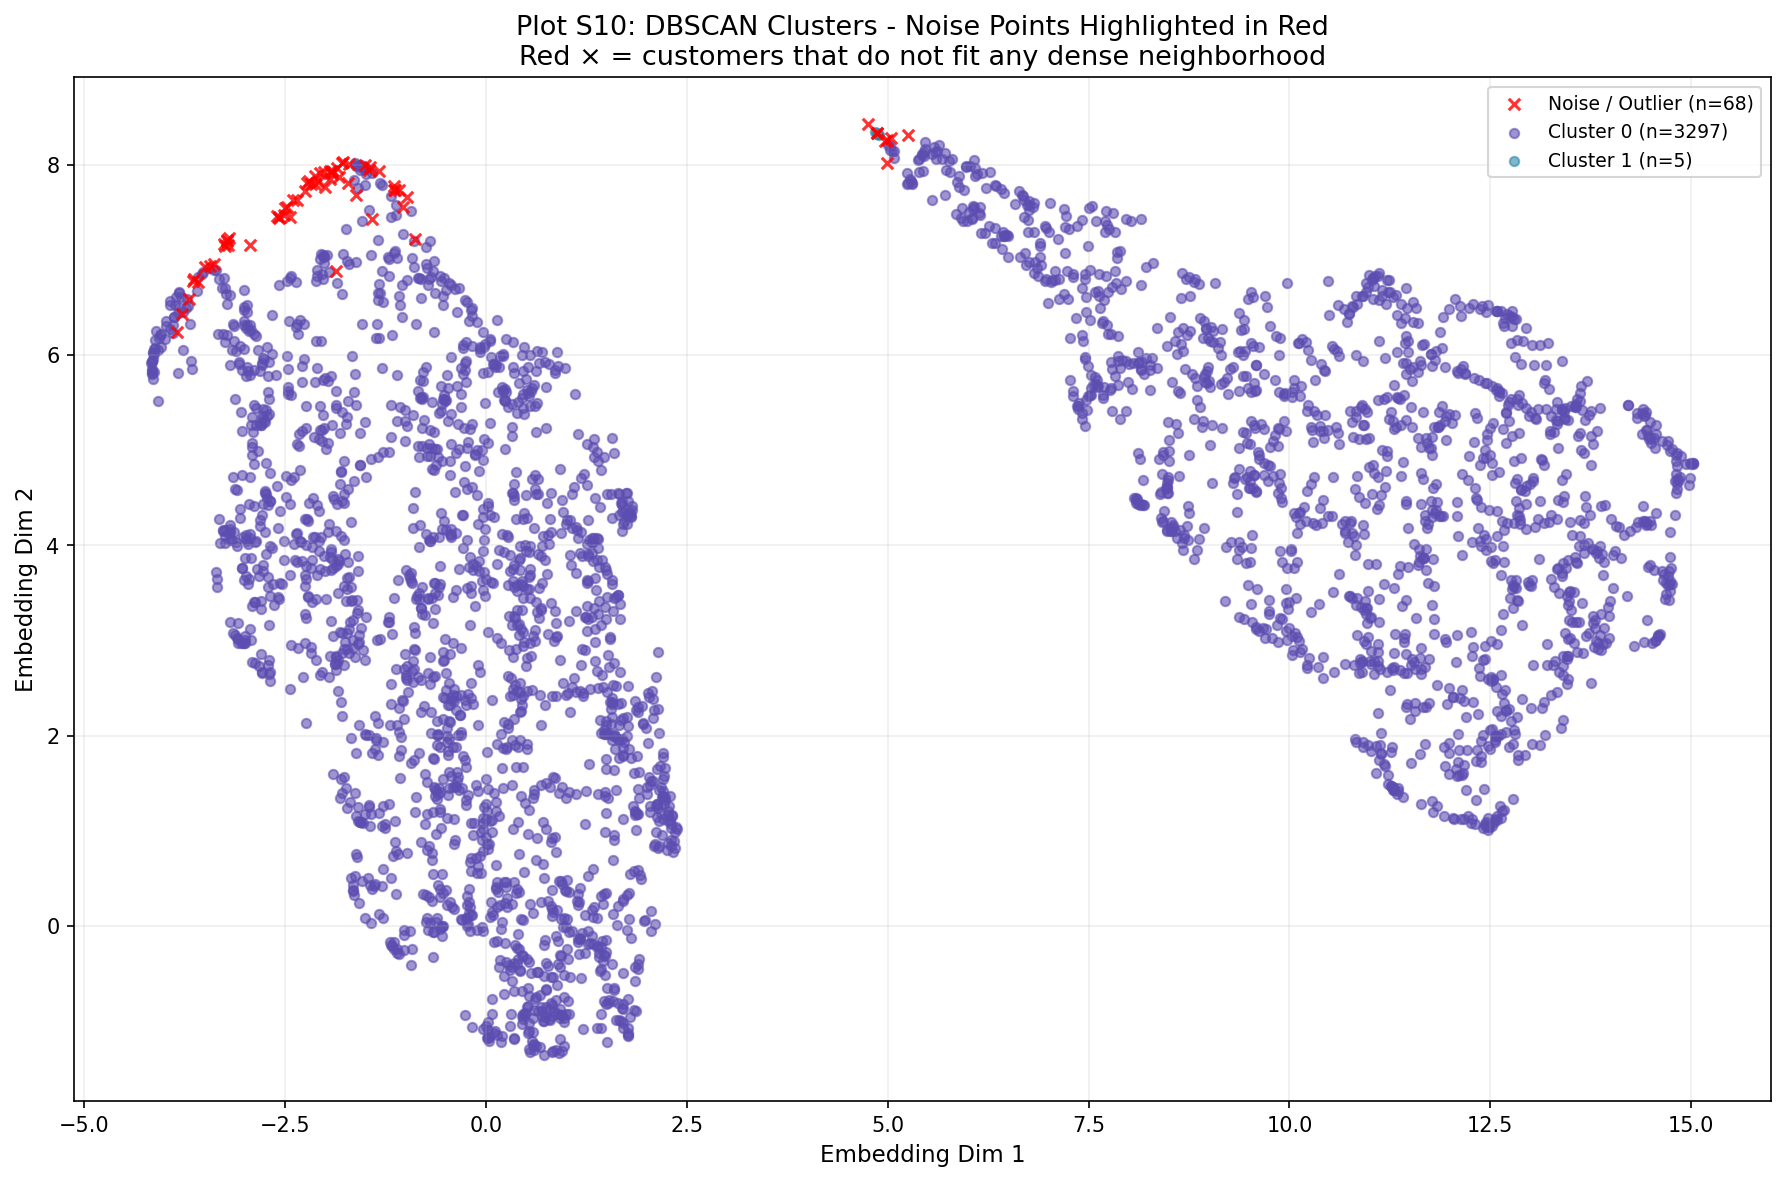

In [10]:
# Cell 7 — Display All Diagnostic Plots
from IPython.display import Image, display

plots = [
    ("seg_elbow_silhouette.png", "Plot S1+S2: Elbow Method + Silhouette Score"),
    ("seg_pca_variance.png",     "Plot S9: PCA Scree + Cumulative Variance"),
    ("seg_umap.png",             "Plot S3: UMAP 2D Cluster Embedding"),
    ("seg_tsne.png",             "Plot S4: t-SNE 2D Cluster Embedding"),
    ("seg_cluster_profiles.png", "Plot S5: Cluster Feature Profile Heatmap"),
    ("seg_clv_heatmap.png",      "Plot S6: Segment x CLV Tier Heatmap"),
    ("seg_dendrogram.png",       "Plot S7: Hierarchical Clustering Dendrogram"),
    ("seg_rfm_3d.png",           "Plot S8: RFM 3D Scatter by Segment"),
    ("seg_dbscan_map.png",       "Plot S10: DBSCAN Noise Map"),
]

for fname, title in plots:
    path = GRAPHS_DIR / fname
    if path.exists():
        print(f"\n--- {title} ---")
        display(Image(str(path)))
    else:
        print(f"[SKIPPED] {fname} not found")


In [11]:
# Fix: explicitly save the 3 CSVs
from src.config import GRAPHS_DIR
import pandas as pd

seg_results['customer_df'].to_csv(GRAPHS_DIR / 'customer_segments.csv', index=False)
seg_results['profiles'].to_csv(GRAPHS_DIR / 'segment_profiles.csv')

import pandas as pd
metrics_df = pd.DataFrame([seg_results['metrics']])
metrics_df.to_csv(GRAPHS_DIR / 'segmentation_metrics.csv', index=False)

print("Saved all 3 CSVs")

Saved all 3 CSVs


In [12]:
# Cell 8 — Final Summary

print("=" * 65)
print("  CUSTOMER INTELLIGENCE PLATFORM")
print("  Segmentation Pipeline Complete")
print("=" * 65)
print(f"  Models trained  : K-Means, DBSCAN, GMM, Hierarchical")
print(f"  Visualizations  : PCA, UMAP, t-SNE")
print(f"  Optimal clusters: {seg_results['optimal_k']}")
print(f"  Silhouette score: {seg_results['metrics']['silhouette']:.4f}")

saved_files = [
    "seg_elbow_silhouette.png", "seg_umap.png", "seg_tsne.png",
    "seg_cluster_profiles.png", "seg_clv_heatmap.png", "seg_dendrogram.png",
    "seg_rfm_3d.png", "seg_pca_variance.png", "seg_dbscan_map.png",
    "customer_segments.csv", "segment_profiles.csv", "segmentation_metrics.csv",
]

print("\nFiles saved to Drive:")
for f in saved_files:
    path = GRAPHS_DIR / f
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {f}")

bundle_path = MODELS_DIR / "segmentation_bundle.pkl"
print(f"  [{"OK" if bundle_path.exists() else "MISSING"}] segmentation_bundle.pkl")

print("\nNext steps:")
print("  1. Run anomaly.py for fraud/return anomaly detection")
print("  2. Add Segments tab to streamlit_app.py")
print("  3. Add Anomaly tab to streamlit_app.py")
print("  4. Build FastAPI endpoint")


  CUSTOMER INTELLIGENCE PLATFORM
  Segmentation Pipeline Complete
  Models trained  : K-Means, DBSCAN, GMM, Hierarchical
  Visualizations  : PCA, UMAP, t-SNE
  Optimal clusters: 2
  Silhouette score: 0.5340

Files saved to Drive:
  [OK] seg_elbow_silhouette.png
  [OK] seg_umap.png
  [OK] seg_tsne.png
  [OK] seg_cluster_profiles.png
  [OK] seg_clv_heatmap.png
  [OK] seg_dendrogram.png
  [OK] seg_rfm_3d.png
  [OK] seg_pca_variance.png
  [OK] seg_dbscan_map.png
  [OK] customer_segments.csv
  [OK] segment_profiles.csv
  [OK] segmentation_metrics.csv
  [OK] segmentation_bundle.pkl

Next steps:
  1. Run anomaly.py for fraud/return anomaly detection
  2. Add Segments tab to streamlit_app.py
  3. Add Anomaly tab to streamlit_app.py
  4. Build FastAPI endpoint


In [17]:
import importlib, sys, os, glob

# 1. Kill cached modules
for key in list(sys.modules.keys()):
    if 'anomaly' in key or 'src' in key:
        del sys.modules[key]

# 2. Delete .pyc bytecode files
pyc_files = glob.glob(
    '/content/drive/MyDrive/clv-prediction-engine/src/__pycache__/anomaly*.pyc'
)
for f in pyc_files:
    os.remove(f)
    print(f"Deleted: {f}")

print("✅ Cache cleared")

Deleted: /content/drive/MyDrive/clv-prediction-engine/src/__pycache__/anomaly.cpython-312.pyc
✅ Cache cleared


In [18]:
from src.anomaly import run_anomaly_pipeline

anomaly_results = run_anomaly_pipeline(
    X_train      = X_train,
    X_test       = X_test,
    y_test_raw   = y_test_raw,
    dollar_preds = dollar_preds,
    customer_ids = None,
)


  ANOMALY DETECTION LEADERBOARD
  Model                    Mean Score    Flagged  % Flagged
---------------------------------------------------------------------------
  Isolation Forest             0.1886        170       5.0%
  Autoencoder                  0.1018        104       3.1%
  Ensemble (Combined)          0.1409        128       3.8%

  Business Flags Summary:
  Total customers analysed : 3,370
  Anomalies flagged        : 128  (3.8%)
  High-return customers    : 0
  Whale anomalies          : 0
  Suspicious customers     : 0

  Files saved to: /content/drive/MyDrive/clv-prediction-engine/artifacts/graphs
  Bundle saved  : /content/drive/MyDrive/clv-prediction-engine/artifacts/models/anomaly_bundle.pkl

  Next steps:
  1. Add Anomaly tab to streamlit_app.py
  2. Add Segments tab to streamlit_app.py
  3. Build FastAPI endpoint (api/main.py)


In [3]:
import shutil
from pathlib import Path

REPO = Path('/content/drive/MyDrive/clv-prediction-engine')
ARTIFACTS = REPO / 'artifacts'

for f in [
    ARTIFACTS / 'models' / 'segmentation_bundle.pkl',
    ARTIFACTS / 'models' / 'anomaly_bundle.pkl',
    ARTIFACTS / 'graphs' / 'seg_umap.png',
    ARTIFACTS / 'graphs' / 'seg_clv_heatmap.png',
    ARTIFACTS / 'graphs' / 'seg_cluster_profiles.png',
    ARTIFACTS / 'graphs' / 'seg_elbow_silhouette.png',
    ARTIFACTS / 'graphs' / 'anomaly_score_distribution.png',
    ARTIFACTS / 'graphs' / 'anomaly_feature_importance.png',
    ARTIFACTS / 'graphs' / 'anomaly_return_flags.png',
    ARTIFACTS / 'graphs' / 'customer_segments.csv',
    ARTIFACTS / 'graphs' / 'segment_profiles.csv',
]:
    print(f"{'✅' if f.exists() else '❌'} {f.name}")

✅ segmentation_bundle.pkl
✅ anomaly_bundle.pkl
✅ seg_umap.png
✅ seg_clv_heatmap.png
✅ seg_cluster_profiles.png
✅ seg_elbow_silhouette.png
✅ anomaly_score_distribution.png
✅ anomaly_feature_importance.png
✅ anomaly_return_flags.png
✅ customer_segments.csv
✅ segment_profiles.csv


In [3]:
%%bash
cd /content
git clone https://github.com/DeepShah111/clv-prediction-engine.git repo_push
cd repo_push
git status
echo "✅ Cloned successfully"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
✅ Cloned successfully


Cloning into 'repo_push'...


In [4]:
%%bash
DRIVE="/content/drive/MyDrive/clv-prediction-engine"
REPO="/content/repo_push"

# Models
cp "$DRIVE/artifacts/models/segmentation_bundle.pkl" "$REPO/artifacts/models/"
cp "$DRIVE/artifacts/models/anomaly_bundle.pkl"      "$REPO/artifacts/models/"

# Segmentation graphs
cp "$DRIVE/artifacts/graphs/seg_umap.png"            "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/seg_clv_heatmap.png"     "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/seg_cluster_profiles.png" "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/seg_elbow_silhouette.png" "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/seg_tsne.png"            "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/seg_rfm_3d.png"          "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/seg_dendrogram.png"      "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/seg_pca_variance.png"    "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/seg_dbscan_map.png"      "$REPO/artifacts/graphs/"

# Anomaly graphs
cp "$DRIVE/artifacts/graphs/anomaly_score_distribution.png"  "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/anomaly_feature_importance.png"  "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/anomaly_return_flags.png"        "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/anomaly_umap.png"                "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/anomaly_reconstruction_error.png" "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/anomaly_top_customers.png"       "$REPO/artifacts/graphs/"

# CSVs
cp "$DRIVE/artifacts/graphs/customer_segments.csv"    "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/segment_profiles.csv"     "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/segmentation_metrics.csv" "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/anomaly_scores.csv"       "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/anomaly_top50.csv"        "$REPO/artifacts/graphs/"
cp "$DRIVE/artifacts/graphs/high_return_customers.csv" "$REPO/artifacts/graphs/"

# Source files
cp "$DRIVE/src/segmentation.py" "$REPO/src/"
cp "$DRIVE/src/anomaly.py"      "$REPO/src/"

# Notebook
cp "$DRIVE/notebooks/segmentation.ipynb" "$REPO/notebooks/"

echo "✅ All files copied"
ls "$REPO/artifacts/models/"
ls "$REPO/artifacts/graphs/" | head -20

✅ All files copied
anomaly_bundle.pkl
clv_champion_bundle.pkl
segmentation_bundle.pkl
accuracy_check.png
anomaly_feature_importance.png
anomaly_reconstruction_error.png
anomaly_return_flags.png
anomaly_score_distribution.png
anomaly_scores.csv
anomaly_top50.csv
anomaly_top_customers.png
anomaly_umap.png
business_lift.png
calibration_curve.png
customer_segments.csv
feature_importance.png
high_return_customers.csv
residual_analysis.png
seg_cluster_profiles.png
seg_clv_heatmap.png
seg_dbscan_map.png
seg_dendrogram.png
seg_elbow_silhouette.png


cp: cannot stat '/content/drive/MyDrive/clv-prediction-engine/notebooks/segmentation.ipynb': No such file or directory


In [5]:
%%bash
find /content/drive/MyDrive/clv-prediction-engine -name "segmentation.ipynb" 2>/dev/null

In [9]:
import joblib
import torch
from pathlib import Path

DRIVE = Path('/content/drive/MyDrive/clv-prediction-engine')
bundle_path = DRIVE / 'artifacts/models/anomaly_bundle.pkl'

# Load the original bundle
bundle = joblib.load(bundle_path)

# Remove the PyTorch autoencoder — it can't pickle across Python versions
# The IsolationForest alone is sufficient for Streamlit Cloud deployment
bundle_streamlit = {
    'isolation_forest': bundle['isolation_forest'],
    'autoencoder':      None,  # stripped — not picklable across Python versions
    'scaler':           bundle['scaler'],
    'cols_used':        bundle['cols_used'],
    'thresholds':       bundle['thresholds'],
    'weights':          bundle['weights'],
    'metrics':          bundle['metrics'],
    'version':          bundle['version'],
    'timestamp':        bundle['timestamp'],
    'note':             'autoencoder stripped for cross-Python compatibility',
}

# Save back
joblib.dump(bundle_streamlit, bundle_path)
print("✅ Bundle re-saved without PyTorch autoencoder")
print(f"Keys: {list(bundle_streamlit.keys())}")

# Verify it reloads cleanly
test = joblib.load(bundle_path)
print(f"✅ Reload verified | autoencoder: {test['autoencoder']}")

✅ Bundle re-saved without PyTorch autoencoder
Keys: ['isolation_forest', 'autoencoder', 'scaler', 'cols_used', 'thresholds', 'weights', 'metrics', 'version', 'timestamp', 'note']
✅ Reload verified | autoencoder: None
